# **Introducción a los `Tranformers` con Pytorch**

### **Un pequeño ejercicio para "construir" una IA desde cero**

En este notebook, vamos a entender de forma didáctica lo que hay detrás de modelos como ChatGPT, Llama o Claude. Hay que entender que, al final del día, los Modelos de Lenguaje Grande (LLMs) no entienden español o inglés, solo entienden **relaciones matemáticas entre números**.

Construiremos los tres pilares de un bloque **Transformer** usando `PyTorch`:

1. **El hardware:** Preparar el entorno.
2. **Multi-Head Attention:** Cómo las palabras se prestan atención entre sí.
3. **Positional Encoding** Cómo el modelo entiende el orden de las palabras.
4. **El bloque Encoder:** Uniendo todo con conexiones residuales y redes feed-forward.

In [ ]:
import torch

"""
1. DETECCIÓN DE HARDWARE:
Los Transformers realizan millones de multiplicaciones matriciales.
Hacer esto en el procesador (CPU) es lento, por lo que buscamos usar
la tarjeta gráfica (GPU/CUDA en NVIDIA, o MPS en Mac).

Ahora bien, yendo un poco en la contrario, para este ejercicio en específico
una CPU 'decente' es suficiente para aprender la arquitectura básica.
""";

if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Trabajando con GPU NVIDIA: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Trabajando con chip de Apple.")
else:
    device = torch.device("cpu")
    print(f"Trabajando con: {device}.")

Trabajando con: cpu.


**1. Multi-Head Attention:**

El mecanismo de **Self-Attention** permite que el modelo mire otras palabras de la frase para entender el contexto de la palabra actual. 

Para lograrlo, cada palabra se divide en tres vectores, aprendidos durante el entrenamiento:
* **Query (Q):** Lo que la palabra está buscando.
* **Key (K):** Lo que la palabra tiene para ofrecer.
* **Value (V):** El contenido real de la palabra.

La fórmula matemática es:
$$Attention(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Multi-Head:** En lugar de hacer esto una sola vez, lo hacemos varias veces en paralelo. Cada "cabeza" (head) es como un "agente" o "detective" que se fija en algo distinto: gramática, sujeto-verbo, emociones, etc.

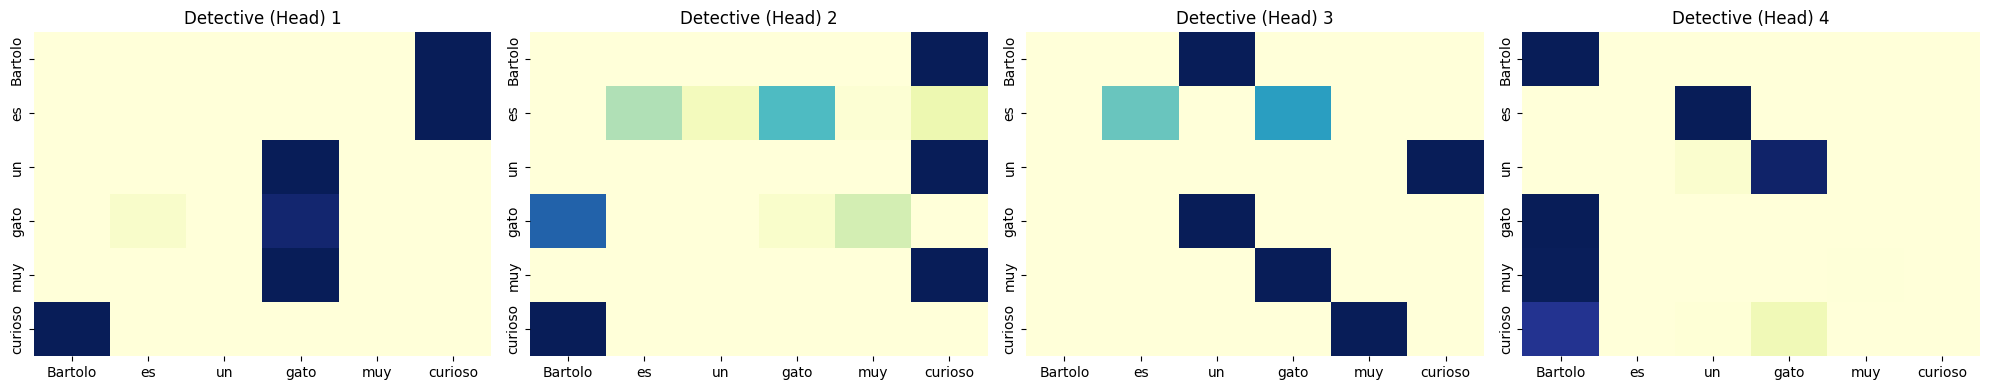

In [8]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de nuestra frase de prueba
frase = "Bartolo es un gato muy curioso"
labels = frase.split()
n_palabras = len(labels)

d_model = 16  # Dimensión total del "significado" de cada palabra
n_heads = 4   # Número de "detectives" trabajando en paralelo
d_head = d_model // n_heads # A cada detective le tocan 4 dimensiones

# Generamos la frase simulando embeddings (números aleatorios por ahora)
x = torch.randn(n_palabras, d_model)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

# Simulamos el trabajo de los 4 detectives
for i in range(n_heads):
    # Matrices de pesos (En la vida real, el modelo aprende estos números)
    Wq = torch.randn(d_model, d_head)
    Wk = torch.randn(d_model, d_head)
    
    # Proyecciones: Multiplicamos la entrada por los pesos
    Q = x @ Wq
    K = x @ Wk
    
    # Scaled Dot-Product: Calculamos la afinidad y la dividimos por la raíz cuadrada
    # de la dimensión para evitar que el Softmax se vuelva muy extremo.
    scores = (Q @ K.T) / (d_head ** 0.5)
    
    # Softmax convierte los "scores" en porcentajes que suman 1 (o 100%)
    weights = F.softmax(scores, dim=-1).detach().numpy()
    
    # Visualización
    sns.heatmap(weights, annot=False, cmap="YlGnBu", 
                xticklabels=labels, yticklabels=labels, 
                ax=axes[i], cbar=False)
    axes[i].set_title(f"Detective (Head) {i+1}")

plt.tight_layout()
plt.show()

**2. Positional Encoding: El "GPS" de las palabras**

A diferencia de nosotros, el `Transformer` lee todas las palabras al mismo tiempo. Para él, "perro muerde hombre" y "hombre muerde perro" son idénticos si no le decimos el orden.

Para solucionarlo, inyectamos una "señal de radio" en cada palabra usando funciones sinusoidales. Las posiciones pares usan el **Seno** y las impares el **Coseno**:

$$PE_{(pos, 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$
$$PE_{(pos, 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$

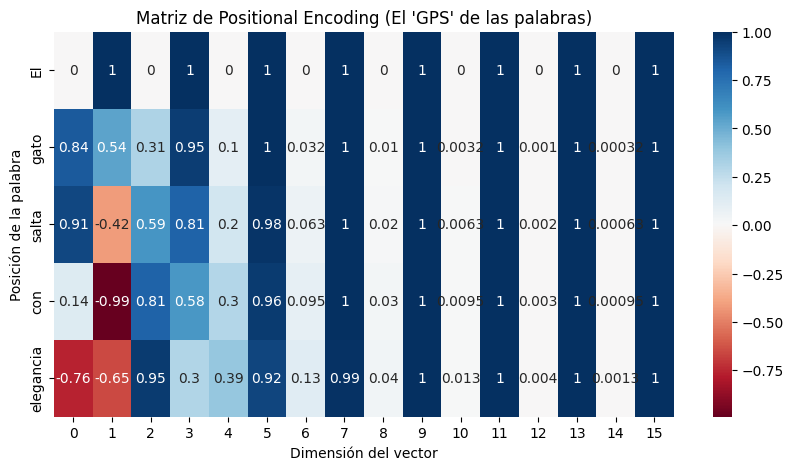

In [9]:
import numpy as np

frase_gatos = "El gato salta con elegancia"
labels = frase_gatos.split()
n_palabras = len(labels)
d_model = 16 

def get_positional_encoding(seq_len, d_model):
    """
    Genera la matriz de posiciones matemáticas.
    Devuelve un tensor con el mismo tamaño que nuestros embeddings.
    """
    pe = torch.zeros(seq_len, d_model)
    position = torch.arange(0, seq_len, dtype=torch.float).unsqueeze(1)
    
    # El divisor matemático (frecuencia de las ondas)
    div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
    
    # Aplicamos Seno a pares y Coseno a impares
    pe[:, 0::2] = torch.sin(position * div_term) 
    pe[:, 1::2] = torch.cos(position * div_term) 
    return pe

pe_matrix = get_positional_encoding(n_palabras, d_model)

# Visualizamos la "huella digital" de cada posición
plt.figure(figsize=(10, 5))
sns.heatmap(pe_matrix.numpy(), annot=True, cmap="RdBu", xticklabels=range(d_model), yticklabels=labels)
plt.title("Matriz de Positional Encoding (El 'GPS' de las palabras)")
plt.xlabel("Dimensión del vector")
plt.ylabel("Posición de la palabra")
plt.show()

**3. El bloque `Encoder` completo**

Para que el modelo aprenda de verdad sin olvidar información pasada, necesitamos envolver nuestra `attention` en un bloque estructurado. Esto incluye:

1. **Atención (Self-Attention)**
2. **Normalización (LayerNorm):** Para estabilizar los números.
3. **Conexiones Residuales (Add):** Sumar la entrada original a la salida para no perder el contexto.
4. **Feed-Forward (FFN):** Una red neuronal clásica para procesar lo que descubrieron los detectives.

In [12]:
import torch.nn as nn

# Frase final de prueba
frase = "Tu gato Bartolo es muy elegante"
labels = frase.split()
n_palabras = len(labels)
d_model = 16

# --- FASE 1: Preparar Entradas ---
x = torch.randn(n_palabras, d_model) # 1. Palabras a números (Embeddings)
pe = get_positional_encoding(n_palabras, d_model) # 2. Generar GPS
x = x + pe # 3. Inyectar GPS en las palabras

# Guardamos una copia para la conexión residual
entrada_original = x.clone() 

# --- FASE 2: Multi-Head Attention (Simplificado) ---
Wq, Wk, Wv = torch.randn(d_model, d_model), torch.randn(d_model, d_model), torch.randn(d_model, d_model)
Q, K, V = x @ Wq, x @ Wk, x @ Wv
scores = (Q @ K.T) / (d_model**0.5)
attn_weights = F.softmax(scores, dim=-1)
atencion_out = attn_weights @ V

"""
--- FASE 3: Add & Norm (Primer guardaespaldas) ---
Sumamos la entrada original (Residual) y normalizamos.
""";
x = F.layer_norm(entrada_original + atencion_out, [d_model])

"""
--- FASE 4: Feed-Forward Network ---
# Una red lineal sencilla que amplía la dimensión temporalmente y la vuelve a reducir.
""";
ffn_out = F.relu(x @ torch.randn(d_model, d_model * 2)) @ torch.randn(d_model * 2, d_model)

# --- FASE 5: Add & Norm Final ---
resultado_final = F.layer_norm(x + ffn_out, [d_model])

print("--------------------------------------------------")
print(f"Frase analizada: '{frase}'")
print(f"Cantidad de tokens (palabras): {n_palabras}")
print(f"Forma del tensor final: {resultado_final.shape}")
print("--------------------------------------------------")
print("El tensor resultante ya contiene información contextualizada.")

--------------------------------------------------
Frase analizada: 'Tu gato Bartolo es muy elegante'
Cantidad de tokens (palabras): 6
Forma del tensor final: torch.Size([6, 16])
--------------------------------------------------
El tensor resultante ya contiene información contextualizada.
